# **AAI 521 - Group 7 Final Project SLAM-Lite Pipeline**

Contributers: Christopher Mendoza, Payal Patel, Tommy Poole

- Goal: Develop a simplified “SLAM-Lite” visual mapping pipeline using the GrapeSLAM UAV dataset that reconstructs a 3D scene and estimates the drone’s path from monocular camera images.

- Learning Objective: Apply computer vision (feature detection, optical flow, pose estimation) to autonomous navigation challenges

### Imports + Load Cached EDA Outputs

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, cv2, math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import imageio
from tqdm import tqdm

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Same path as EDA notebook
DRIVE_BASE = "/content/drive/MyDrive/SLAM_Lite"

# Using the same flight index as in the EDA notebook
FLIGHT_IDX = 2

# In my EDA I accidentally overwrote so that's why the structure is like this
flight_cache = os.path.join(
    DRIVE_BASE,
    "eda_pat",
    f"flight_{FLIGHT_IDX:02d}",
    f"flight_{FLIGHT_IDX:02d}",
    f"flight_{FLIGHT_IDX:02d}",
)

print("Using: ", flight_cache)

# Load cached outputs from EDA notebook
frames = np.load(os.path.join(flight_cache, "frames.npy"))
df_m = pd.read_csv(os.path.join(flight_cache, "metrics.csv"))
pairs = [tuple(p) for p in np.load(os.path.join(flight_cache, "pairs.npy"))]

print("Frame shape: ", frames.shape)
print("Number of frame pairs: ", len(pairs))

Using:  /content/drive/MyDrive/SLAM_Lite/eda_pat/flight_02/flight_02/flight_02
Frame shape:  (154, 224, 224, 3)
Number of frame pairs:  153


## Modeling Methods

To build a lightweight Visual Odometry (VO) system that is suitable for embedded UAV navigation, we implemented a feature based VO pipeline. This method processes video frames, extracts visual features, matches them across time, estimates camera motion, and recontructs a 3D map.

This SLAM-Lite Pipeline includes:
1. Feature Detection (ORB)
2. Feature Matching (BFMatcher)
3. Pose Estimation using Essential Matrix + recoverPose
4. Trajectory Integration
5. Mapping via Triangulation


In [3]:
# Reuse the same grayscale function from our EDA
def gray(rgb_frame):
  gray_frame = cv2.cvtColor((rgb_frame * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
  return gray_frame.astype(np.float32) / 255.0

### Camera Intrinsics (Same for all flights)

In [4]:
# Double check image size from our preprocessing frames
H, W = frames.shape[1:3]
print(W, "x", H)

# Minimal monocular intrinsics
fx = fy = 800.0
cx, cy = W / 2, H / 2

K = np.array([
    [fx, 0, cx],
  	[0, fy, cy],
    [0, 0, 1]
], dtype=np.float32)

print("Intrinsic matrix K: \n", K)

224 x 224
Intrinsic matrix K: 
 [[800.   0. 112.]
 [  0. 800. 112.]
 [  0.   0.   1.]]


### Feature Detection

We used ORB because:

- It is fast and lightweight (computationally)
- uitable for embedded drones
- Robust to rotation

In [5]:
# Detect ORB keypoints and descriptors
def detect(gray_img, orb):
  img_uint8 = (gray_img * 255).astype(np.uint8)
  key_p, desc = orb.detectAndCompute(img_uint8, None)
  return key_p, desc

### Feature Matching - BFMatcher

In [6]:
# Match ORB descriptors using KNN + Lowe's ratio test
def match_desc(desc1, desc2, ratio=0.75):
  bf = cv2.BFMatcher(cv2.NORM_HAMMING)
  knn_matches = bf.knnMatch(desc1, desc2, k=2)
  good_matches = []
  for best, n in knn_matches:
    if best.distance < ratio * n.distance:
      good_matches.append(best)
  return good_matches

### Pose Estimation - Essential Matrix + recoverPose

In [7]:
# Estimate rotation and translation using Essential Matrix
def pose_estimate(keypts_1, keypts_2, matched_feat, k):
  if len(matched_feat) < 8:
    return None, None, 0.0

  pose_1 = np.float32([keypts_1[m.queryIdx].pt for m in matched_feat])
  pose_2 = np.float32([keypts_2[m.trainIdx].pt for m in matched_feat])

  essen_matrix, mask = cv2.findEssentialMat(pose_1, pose_2, k, cv2.RANSAC, 0.999, 1.0)
  if essen_matrix is None:
    return None, None, 0.0

  _, R, t, mask = cv2.recoverPose(
      essen_matrix,
      pose_1,
      pose_2,
      k,
      mask=mask
  )
  return R, t, essen_matrix.shape[1]

###Trajectory Integration

In [8]:
# detect -> match -> pose -> integrate
def run_debug_vo(frames, pairs, K):
    orb_extr = cv2.ORB_create(nfeatures=1500)

    num_frames = len(frames)
    esti_poses = [np.eye(4, dtype=np.float32) for _ in range(num_frames)]
    trajec_poses  = np.zeros((num_frames, 3), dtype=np.float32)

    vo_debug_log = []

    for (idx_a, idx_b) in pairs:
        g1 = gray(frames[idx_a])
        g2 = gray(frames[idx_b])

        keypts_a, desc_a = detect(g1, orb_extr)
        keypts_b, desc_b = detect(g2, orb_extr)

        if desc_a is None or desc_b is None:
            vo_debug_log.append({"pair": (idx_a, idx_b), "matches": 0})
            continue

        matched_feat = match_desc(desc_a, desc_b)
        R, t, inlier_ratio = pose_estimate(keypts_a, keypts_b, matched_feat, K)

        vo_debug_log.append({
            "pair": (idx_a, idx_b),
            "matches": len(matched_feat),
            "inliers": inlier_ratio
        })

        if R is None:
            continue

        relative_transform = np.eye(4)
        relative_transform[:3, :3] = R
        relative_transform[:3, 3] = t.squeeze()

        esti_poses[idx_b] = esti_poses[idx_a] @ relative_transform
        trajec_poses[idx_b] = esti_poses[idx_b][:3, 3]

    return esti_poses, trajec_poses, vo_debug_log

In [9]:
# Run VO
poses_est, traj_est, vo_debug_log = run_debug_vo(frames, pairs, K)
print("Trajectory shape:", traj_est.shape)

Trajectory shape: (154, 3)


### Plot Estimated Trajectory

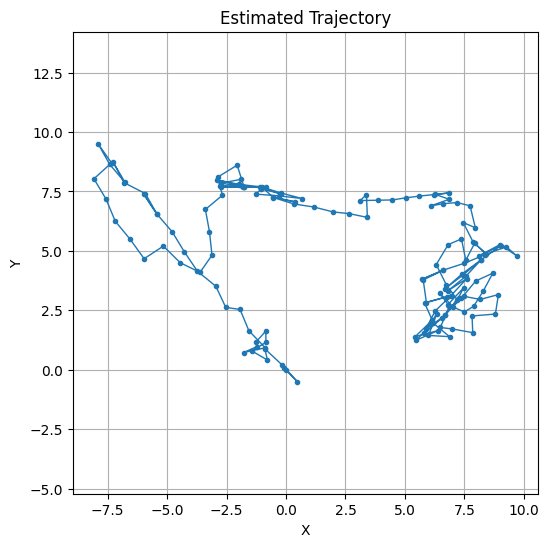

In [10]:
# Plot trajectory
plt.figure(figsize=(6,6))
plt.plot(traj_est[:,0], traj_est[:,1], marker='.', linewidth=1)
plt.title("Estimated Trajectory")
plt.xlabel("X")
plt.ylabel("Y")
plt.axis("equal")
plt.grid(True)
plt.show()

###3D Mapping via Triangulation

In [11]:
# Triangulate 3D points using projection matrices
def triang_point(keypts_1, keypts_2, matched_feat, K, pose_a, pose_b):
    if len(matched_feat) < 12:
        return np.zeros((0,3))

    pts1 = np.float32([keypts_1[m.queryIdx].pt for m in matched_feat]).T
    pts2 = np.float32([keypts_2[m.trainIdx].pt for m in matched_feat]).T

    proj_a = K @ pose_a[:3, :]
    proj_b = K @ pose_b[:3, :]

    pts_4d = cv2.triangulatePoints(proj_a, proj_b, pts1, pts2)
    pts_3d = (pts_4d[:3] / pts_4d[3]).T

    return pts_3d

In [12]:
# Build 3D map by triangulating every Nth pair
def build_map(frames, pairs, esti_poses, K, step=6):
    orb = cv2.ORB_create(nfeatures=1500)
    all_pts = []

    for (idx_a, idx_b) in pairs[::step]:
        g1 = gray(frames[idx_a])
        g2 = gray(frames[idx_b])

        k1, d1 = detect(g1, orb)
        k2, d2 = detect(g2, orb)
        if d1 is None or d2 is None:
            continue

        matches = match_desc(d1, d2)
        pts = triang_point(k1, k2, matches, K, esti_poses[idx_a], esti_poses[idx_b])

        if len(pts) > 0:
            all_pts.append(pts)

    if not all_pts:
        return np.zeros((0,3))

    return np.vstack(all_pts)

In [13]:
# Generate points
sparse_points = build_map(frames, pairs, poses_est, K)
print("Sparse points:", sparse_points.shape)

Sparse points: (3708, 3)


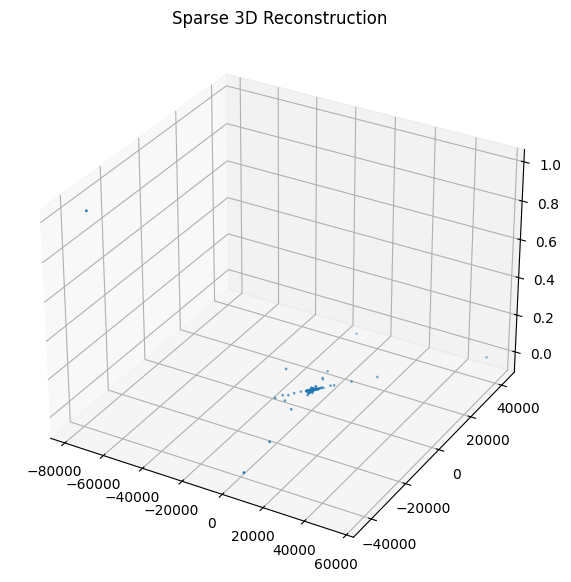

In [14]:
# Plot sparse map
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(sparse_points[:,0], sparse_points[:,1], sparse_points[:,2], s=1)
ax.set_title("Sparse 3D Reconstruction")
plt.show()

In [15]:
# Create video render (just for a visual)
def create_vid(frames, traj, filename="vo_traj.mp4", fps=20):

    vid_frames = []

    # Normalize trajectory for plotting
    x = traj[:,0]
    y = traj[:,1]

    for i in tqdm(range(5, len(frames))):
        fig, axes = plt.subplots(1, 2, figsize=(10,5))

        # Show frame
        axes[0].imshow(frames[i])
        axes[0].set_title(f"Frame {i}")
        axes[0].axis("off")

        # Plot trajectory
        axes[1].plot(x[:i], y[:i], linewidth=2)
        axes[1].scatter(x[i], y[i], color="red")
        axes[1].set_title("Estimated Trajectory")
        axes[1].set_xlabel("X")
        axes[1].set_ylabel("Y")
        axes[1].grid(True)
        axes[1].set_aspect("equal", adjustable="box")
        fig.tight_layout()

        # Convert figure to RGB image
        fig.canvas.draw()
        bf = fig.canvas.buffer_rgba()
        frame = np.asarray(bf)[:, :, :3]
        vid_frames.append(frame)

        plt.close(fig)

    # Save video
    imageio.mimsave(filename, vid_frames, fps=fps)
    print("Saved:", filename)

create_vid(frames, traj_est)

100%|██████████| 149/149 [00:26<00:00,  5.53it/s]


Saved: vo_traj.mp4


In [16]:
from google.colab import files
files.download("vo_traj.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

(np.float64(-0.5), np.float64(1007.5), np.float64(511.5), np.float64(-0.5))

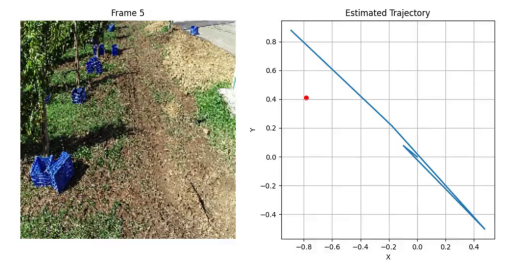

In [17]:
# Plot start of video
vid_traj = imageio.mimread("/content/vo_traj.mp4", memtest=False)
plt.imshow(vid_traj[0])
plt.axis("off")

(np.float64(-0.5), np.float64(1007.5), np.float64(511.5), np.float64(-0.5))

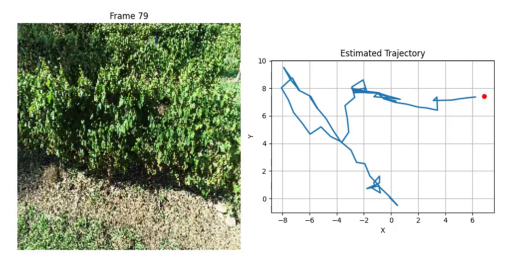

In [18]:
# Middle of video
plt.imshow(vid_traj[len(vid_traj)//2])
plt.axis("off")

(np.float64(-0.5), np.float64(1007.5), np.float64(511.5), np.float64(-0.5))

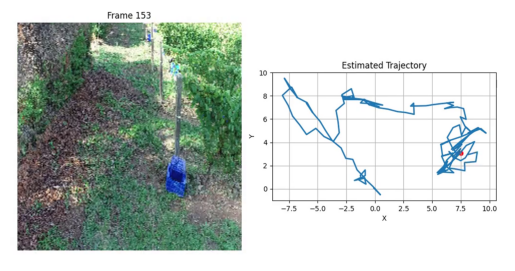

In [19]:
# End of video
plt.imshow(vid_traj[-1])
plt.axis("off")